## Problem: Predict House Rent Based on Size

Scenario:
We want to predict the monthly rent of apartments based on square footage.

## 1. Dataset (synthetic for practice):


| Size (sq.ft) | Rent ($) |
| ------------ | -------- |
| 500          | 1500     |
| 700          | 2000     |
| 800          | 2200     |
| 1000         | 2700     |
| 1200         | 3000     |


In [4]:
import pandas as pd

data={ 'Size(sq.ft)': [500,700,800,1000,1200],
       'Rent($)':[1500,2000,2200,2700,3000]
     }
df= pd.DataFrame(data)
print(df)

   Size(sq.ft)  Rent($)
0          500     1500
1          700     2000
2          800     2200
3         1000     2700
4         1200     3000


## 2. Data Visualization
- We would plot a scatter plot of the dataset to check the relationship between our variables.
- From the plot below, we can see the graph has an upward trend, meaning as the area increases, so does the rent.
- As the nature of the data is linear we can try Linear Regression model on our dataset.

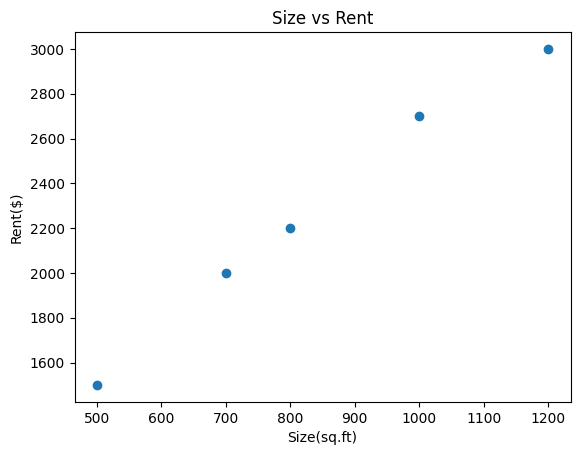

In [16]:
import matplotlib.pyplot as plt

plt.scatter(df['Size(sq.ft)'], df['Rent($)'])
plt.xlabel('Size(sq.ft)')
plt.ylabel('Rent($)')
plt.title('Size vs Rent')
plt.show()
            

## 3. Feature and Traget selection
- **Feature(X)**: The input variables which we use for prediction. Also known as predictor. Also known as independent variable.
- **Target(y)**: The variable we want to predict/ Dependent variable

In this example:

- **Size of the house** is the feature.
- **Rent** is the target.

The goal of the model is to learn the relationship between the **Size of the house** and **Rent**

In [10]:
X= df[['Size(sq.ft)']]
y= df['Rent($)']

## 4. Model Training
We now train a Linear Regression model.

Linear regression attempts to find the best-fitting straight line that represents the relationship between the feature and the target.

The mathematical form of the model is:

Rent = m × Size_of_the_house + b

Where:

- **m** is the slope (how much rent changes per square foot)
- **b** is the intercept (predicted rent when size is 0)
- The model learns these parameters from the data.

In [11]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(X, y)

LinearRegression()

## 5. Predictions
- After training the model, we use it to predict Rent based on the size of the house
- These predictions will form the regression line, which represents the model's estimate of the relationship between Rent and size.
  
### Why Predict on Training Data First?

Even though the model has already seen this data, predicting on the training dataset serves several important purposes:

1. **Visualizing the Regression Line**

   
   - We use the predicted values (`y_pred`) to draw the regression line over the scatter plot.  
   - This helps us **see how well the model captures the trend** in the data.

3. **Understanding Model Fit**

   
   - By comparing the predicted values with actual values, we can calculate **residuals** (Actual − Predicted).  
   - Residuals show how far off the model’s predictions are and help us **assess the accuracy** of the fit.

5. **Debugging & Checking for Issues**

   
   - Predicting on known data lets us spot **outliers** or **incorrect trends**.  
   - If the line looks completely off, we know something went wrong in training or data preparation.

7. **Foundation for Unseen Data Predictions**

   
   - Once we confirm that the model fits the training data reasonably well, we can **confidently predict new/unseen data**.  
   - This step ensures our model generalizes correctly when applied to real-world inputs.

**Key Idea:** Predicting on training data is mainly for **visualization, understanding, and verification**, while predicting on new data is where the model truly demonstrates its usefulness.


In [14]:
y_pred= model.predict(X)
print(y_pred)

[1541.78082192 1976.02739726 2193.15068493 2627.39726027 3061.64383562]


## 6. Regression Line Visualization

- The regression line represents the best fitting straight line learned by the model.

- It passes through the data in a way that minimizes the difference between the actual Rent and the predicted Rent.

- Points above or below the line indicate prediction errors.

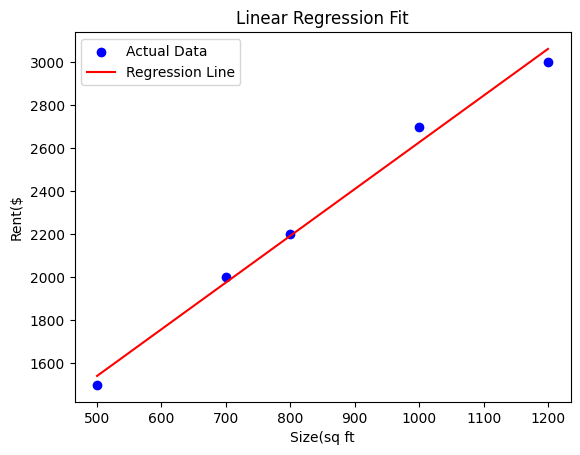

In [23]:

import matplotlib.pyplot as plt

# Scatter points (actual data)
plt.scatter(X, y, color='blue', label='Actual Data')

# Regression line (predicted on training data)
plt.plot(X, y_pred, color='red', label='Regression Line')

# Labels and title
plt.xlabel("Size(sq ft")
plt.ylabel("Rent($")
plt.title("Linear Regression Fit")

# Add legend
plt.legend()

# Show plot
plt.show()

## 7. Model Parameters
After training the model, we can inspect the learned parameters:

- **Slope (Coefficient)**: shows how much the predicted rent increases when sizes increase by one unit.
- **Intercept***: the predicted rent when size is zero.
  
These parameters define the regression equation learned by the model.

In [24]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 2.1712328767123292
Intercept: 456.1643835616435


## 8. Residual Analysis
A residual is the difference between the actual value and the predicted value.

Residual = Actual − Predicted

Residual plots help us understand how well the model fits the data.
If the residuals are randomly scattered around zero, the linear model is likely appropriate.



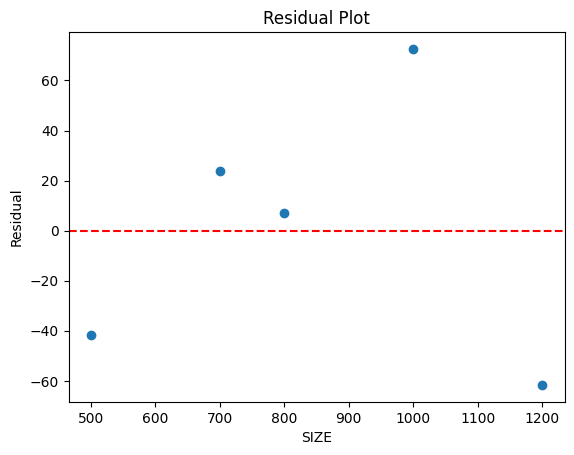

In [25]:
residuals = y - y_pred

plt.scatter(X, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("SIZE")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()